*updated 11 Aug 2025, Julian Mak (whatever with copyright, do what you want with this)

### As part of material for OCES 4303 "AI and Machine Learning in Marine Science" delivered at HKUST

For the latest version of the material, go to the public facing [GitHub](https://github.com/julianmak/OCES4303_ML_ocean) page.

---
# 9. Convolutional Neural Networks

In the previous case we considered perceptrons and multi-layer neural networks. The fully connected nature of those networks means the degrees of freedom is large and often become unwieldly. ***Convolution Neural Networks*** (CNNs) has an advantage in controlling the dimensionality of the networks, and have been found to be particularly skillful / lend themselves naturally to dealing image/array data (e.g. for computer vision problems). That is the focus of this session.

But first I am going to take a big-ish detour and introduce the use `pytorch`.

> ## Key Objective(s)
> 1. Use of `pytorch` as an engine in the creation and training of neural networks, and quickly re-do some of the things considered in the previous session
> 2. Introduce the idea of a convolution, and the learning of a convolution kernel
> 3. Applying CNNs to the same image classification and regression problem

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler

---
## a) Usage of `pyTorch`

While it is in principle possible to create neural networks by hand (cf. extended exercise in the previous session), there are quite a few libraries/engines out there that are designed to link up the creation of the hidden layers, loss functions and/or optimisers. [PyTorch](https://pytorch.org/) is one of the those that will be considered here; [TensorFlow](https://www.tensorflow.org/) is another. 

> NOTE: Ultimately the above libraries leverage interfaces for manipulating arrays/tensors. In principle [JAX](https://github.com/jax-ml/jax) could also do it, although PyTorch and TensorFlow have higher level calls that make the process a bit easier.
>
> We can use an interface over PyTorch and TensorFlow to make our lives even easier (e.g. `Lightning` and/or `keras`), but I am not going to do that here; see extended exercise if you want to give that a try.

Underlying that engines are methods to manipulate the arrays (as objects called ***tensors***) and assemble things in the appropriate manner in order to train and run the neural networks. In the below I am going to redo the (multi-layer) perceptron cats and dogs classificaion example from last time to demonstrate certain aspects of the engine. First going to load the appropriate data. The below code is basically copy and paste from before, using some of the `sklearn` utilities, and nothing is new thus far.

In [2]:
# don't read the headers

option = "remote"

if option == "local":
    print("loading data locally (assumes file has already been downloaded)")
    path = "cat.csv"
elif option == "remote":
    print("loading data remotely")
    path = "https://raw.githubusercontent.com/julianmak/OCES4303_ML_ocean/refs/heads/main/cat.csv"
else:
    raise ValueError("INVALID OPTION: use 'remote' or 'local'")

df_cats = pd.read_csv(path, header=None).T # make "features" the axis=-1
X_cats = df_cats.values

if option == "local":
    print("loading data locally (assumes file has already been downloaded)")
    path = "dog.csv"
elif option == "remote":
    print("loading data remotely")
    path = "https://raw.githubusercontent.com/julianmak/OCES4303_ML_ocean/refs/heads/main/dog.csv"
else:
    raise ValueError("INVALID OPTION: use 'remote' or 'local'")

df_dogs = pd.read_csv(path, header=None).T # make "features" the axis=-1
X_dogs = df_dogs.values

# shape of "cats" and "dogs" here is (pixels, index), so it is already flattened
n = 64  # take the first 80% (out of 80 entries) of the data just because

X_train = np.concatenate((X_cats[:n, :], X_dogs[:n, :]), axis=0)  # combine
Y_train = np.concatenate((np.ones(n), np.zeros(n)))         # label: cats = 1 and dogs = 0

X_test = np.concatenate((X_cats[n::, :], X_dogs[n::, :]), axis=0)
Y_test = np.concatenate((np.ones(80-n), np.zeros(80-n)))

# scale and redefine the data
scaler = StandardScaler()
scaler.fit(X_train)
X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)

loading data remotely
loading data remotely


From hereon we invoke `PyTorch` utilities. Zeroth thing we do is to load some packages. Then we are going to proceed as follows:

1) Convert the data accordingly into things `PyTorch` can manipulate
2) Define the MLP
3) Define relevant loss function and optimisers
4) Package up the parts in a training loop that is to be iterated on
5) Train the model and evaluate things accordingly

In [3]:
# load package and data
import torch
import torch.nn as nn
import torch.optim as optim

### 1. Convert data into tensor objects

For the present classification problem the inputs we have were integers, and after the usual standardisation are floats, which are converted into pytorch tensors as `FloatTensor`. The outputs really are integers, and this could be done as `LongTensor` (if it is SIGNED) or `ByteTensor` (if it is UNsigned); I am going to use `LongTensor` even though I don't strictly need to (since my labels are `0` and `1`s).

> NOTE: `FloatTensor` here is `float32` rather than `float64`, respecively storing 8 and 16 decimal places.

In [4]:
# data convertion in to pytorch objects
print(f"X_train array shape before = {X_train.shape}")

X_train, X_test = torch.FloatTensor(X_train), torch.FloatTensor(X_test)
Y_train, Y_test = torch.LongTensor(Y_train), torch.LongTensor(Y_test)

print(f"X_train tensor size after = {X_train.size()}")
print(" ")

X_train array shape before = (128, 4096)
X_train tensor size after = torch.Size([128, 4096])
 


Converting to tensor objects have some advantages with regards to reshaping and so forth, to be demonstrated later.

### 2. Define the MLP structure

The below code define the neural network structure as a class object which can be passed around.

* The model is called `nn_classify_pets`, and it includes `nn.Module` as a generic interface to receive inputs accordingly (but we won't have any here as such).
* The `__init__` initialises the class with things it needs. The `super` part is for some inheritance reasons so that the `PyTorch` interface needs to see when doing the training later.
* The main part is the structure which I wrote in one go in `self.layers`:
  - `nn.Sequential` means all the things in that part are run sequentially in the specified order
  - `nn.Linear(64**2, 100)` takes inputs of size $64^2$ (i.e. the number of pixels in the flattened image) and pass that to 100 nodes (which is the `sklearn.MLPClassifier` default)
  - You might put then an activation function (e.g. `nn.ReLU()`), although I didn't (which was a choice I made in the last session)
  - `nn.Linear(100, 2)` then takes the 100 nodes and converts to two outputs, because in this particular classification problem I have two possibilities (cats or dogs).

> NOTE: You might argue surely I just want one number given I want to evaluate whether then numbers are closer to `0` or `1` for the classification. That's not how `PyTorch` and the related loss function works; see later.

* To wrap it up, the subroutine `forward` defines how the network does the feed-forward for loss function evaluation, which is needed for recording purposes for the back-propagation later (the recording procedure is sometimes referred to as ***taping*** or ***annotating***).

In [5]:
# define the model architecture

class nn_classify_pets(nn.Module):
    def __init__(self):  # specify input dims below
        super(nn_classify_pets, self).__init__()

        # nest it in one go
        self.layers = nn.Sequential(
            nn.Linear(64**2, 100),  # image is 64**2, 100 nodes (sklearn default)
            # nn.ReLU(),            # no activation function
            nn.Linear(100, 2)       # two possible outputs
        )

    # actual model structure: input -> hidden layer -> outputs, ReLU on input and hidden
    def forward(self, x):
        out =  self.layers(x)
        return out

Should just say that the below is an equivalent way of defining the same thing as above, but in a slightly more verbose way: I define all the components in `__init__`, then assemble it in the order I want in `forward`.

```
class nn_classify_pets(nn.Module):
    def __init__(self):
        super(nn_classify_pets, self).__init__()

        self.input_layer = nn.Linear(64**2, 100)
        self.output_layer = nn.Linear(100, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        out =  self.input_layer(x)
        # out = self.relu(out)  # no activation function here wth comment
        out =  self.output_layer(out)
        return out
```

### 3. Initialise relevant loss function and optimisers

For the binary classification problem we can use `nn.CrossEntropyLoss()` (which is related to the information gain discussed previously), `nn.HingeEmbeddingLoss`, or some others that you can look up; going to use the first one.

For the optimiser there are a variety of these in `torch.optim`; I am going to use `optim.Adam` (which is the default in `sklearn`), but other options are the standard stochastic gradient descent `optim.SGD` or even `optim.LBFGS`, which are also options in `sklearn`. There are also other options, have a look at those if you want.

In the below I manually specify the ***learning rate*** (the step size for iteration towards the local minimum in the loss function landscape), although I am actually using the default value (which is `0.001`). A larger value will speed up the training process, but may also overshoot and lead to non-convergence (which is why I kept it at `0.001` actually).

Here we need to initialise the neural network model in order to pass the model weights to the optimiser; these are the things that will be updated by the optimizer.

> NOTE: I additionally specify a seed to force some reproducibility. Instead of specifying `random_state` this is done as `torch.manual_seed(NUM)`.

In [6]:
# initialisations here only

torch.manual_seed(1234)

model = nn_classify_pets()
learning_rate = 0.001
J = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # default is 0.001

print(f"model details: {model}")
print(" ")
print(f"optimizer details: {optimizer}")
print(" ")

model details: nn_classify_pets(
  (layers): Sequential(
    (0): Linear(in_features=4096, out_features=100, bias=True)
    (1): Linear(in_features=100, out_features=2, bias=True)
  )
)
 
optimizer details: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
 


### 4. Wrap up the training

There are multiple parts to this. Below code wraps everything up in one subroutine `training` (because I am going to call this again and again), and what it does are the following:

* Take in some required inputs (e.g. `model`, `optimizer`, `J`, training data for training, testing data to evalute model performance on unseen data on the fly). The number of training epochs have a default choice, and `out_epoch` is a variable throwing controlling how often diagonstics are throw out to screen.
* `train_J` and `test_J` are variables that will be dumped into with data needed for plotting the loss curves.
* At every cycle of the epoch, we perform the following:
  - clear gradients if they already exist just to avoid contamination with `optimizer.zero_grad()`
  - do a feed-forward with `Y_pred = model(X_train)`
  - evalute the training loss with `J_train = J(Y_pred, Y_train)`, which has been taped/annotated accordingly
  - do back-propagation with `J_train.backward()`, because we have the taping
  - update the model weights with `optimizer.step()` (because the optimizer knows these are the control variables from `optim.Adam(model.parameters(), lr=learning_rate)` before)
* Where relevant, evaluate also the loss value associated with the test set for diagnostic purposes, but the training itself never sees that data.
* Return the final model state and relevant diagnostics once the loop has ended.

In [7]:
# wrap the training up

def training(model, optimizer, J, X_train, Y_train, X_test, Y_test,
             num_epochs=500, out_epoch=50):

    # define things to dump into for loss curve
    train_J = np.zeros(num_epochs)
    test_J  = np.zeros(num_epochs)

    for epoch in range(num_epochs):

        # iteration step
        optimizer.zero_grad()  # clear gradients if it exists (from loss.backward())
        Y_pred = model(X_train)  # feed-forward
        J_train = J(Y_pred, Y_train) # compute loss
        J_train.backward()  # back propagation
        optimizer.step()  # iterate

        # diagnostics: evaluation of metrics as we go along
        Y_pred = model(X_test)
        J_test = J(Y_pred, Y_test)
        train_J[epoch] = J_train.item()
        test_J[epoch] = J_test.item()

        if (epoch + 1) % out_epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, "
                + f"Train Loss: {J_train.item():.4f}, "
                + f"Test Loss: {J_test.item():.4f}")

    return model, train_J, test_J

### 5. Train the model and evaluate it accordingly.

What it says on the tin. Going to train it first, plot the loss functions and then say other things about the evaluation part.

Epoch 20/200, Train Loss: 0.0073, Test Loss: 2.6728
Epoch 40/200, Train Loss: 0.0007, Test Loss: 2.8551
Epoch 60/200, Train Loss: 0.0004, Test Loss: 2.9514
Epoch 80/200, Train Loss: 0.0003, Test Loss: 3.0088
Epoch 100/200, Train Loss: 0.0002, Test Loss: 3.0803
Epoch 120/200, Train Loss: 0.0002, Test Loss: 3.1280
Epoch 140/200, Train Loss: 0.0001, Test Loss: 3.1762
Epoch 160/200, Train Loss: 0.0001, Test Loss: 3.2194
Epoch 180/200, Train Loss: 0.0001, Test Loss: 3.2588
Epoch 200/200, Train Loss: 0.0001, Test Loss: 3.2955


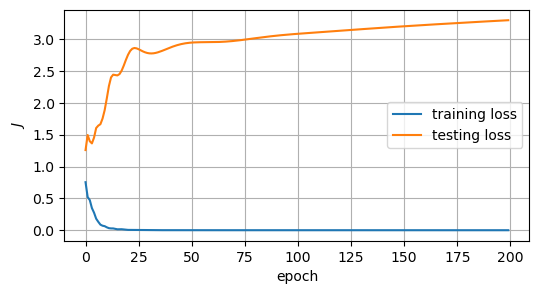

In [8]:
# do the actual training and plot the loss curves
model, train_J, test_J = training(model, optimizer, J, X_train, Y_train, X_test, Y_test,
                                 num_epochs=200, out_epoch=20)

fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
ax.plot(train_J, label="training loss")
ax.plot(test_J, label="testing loss")
ax.set_xlabel("epoch")
ax.set_ylabel(r"$J$")
ax.grid()
ax.legend();

Because all the data is normalised a value above 1 is actually a bad thing. In the above the training loss is decreasing and settling down as it should, but the testing loss is going up somewhat.

We can make predictions by running the model once more. In the below I wrapped out the prediction step with `torch.no_grad()` to force it to not do taping. Strictly speaking it doesn't matter if you never re-run the training again by restarting **properly**; see comment towards the end of the section.

In [9]:
with torch.no_grad():
    predictions_train = model(X_train)
    predictions_test = model(X_test)
print(predictions_train[0:10, :])
print(" ")

tensor([[-11.0572,  10.2664],
        [ -7.6456,   6.9655],
        [ -7.7180,   7.5307],
        [ -3.8594,   2.8557],
        [-12.1541,  11.4050],
        [-21.4537,  19.7752],
        [-15.3331,  13.3581],
        [-12.7377,  11.6583],
        [-20.5274,  17.8370],
        [-10.1459,   8.9547]])
 


The way to read the above output from the neural network for this classification problem is the score for the guess at position `0` (for dogs) and `1` for cats, and we want the **largest positive score**. We can pick out that by cycling through all the samples and using `np.argmax` argument, but we probably want to convert the tensor object back to numpy arrays. This can be done by the imbued function `.numpy()`. The below wraps up the various functions calls in one go as a subroutine, because I am going to reuse it again later.

In [10]:
# do model prediction and evaluate skill
def classification_skill(predictions, truths):
    dum = predictions.numpy()
    Y_pred = np.zeros(dum.shape[0])
    N = len(Y_pred)
    for i in range(N):
        Y_pred[i] = np.argmax(dum[i, :])
    skill_all = np.sum(Y_pred == truths.numpy())

    print(f"overall skill: {skill_all} correct out of {N} ({skill_all/N*100:.2f}%)")
    print(" ")

# plot out the predictions (circles should lie on top of crosses if completely correct)
def classification_plot(predictions, Y_test):

    dum = predictions.numpy()
    Y_pred = np.zeros(dum.shape[0])
    N = len(Y_pred)
    for i in range(N):
        Y_pred[i] = np.argmax(dum[i, :])
    
    fig = plt.figure(figsize=(10, 2))
    ax = plt.axes()
    ax.plot(Y_pred, 'bx', label="predictions")
    ax.plot(Y_test, 'ro', fillstyle="none", label="truth")
    ax.plot([15.5, 15.5], [-0.3, 1.3], 'k--', alpha=0.7)
    ax.set_xlabel("index")
    ax.legend()
    ax.grid()
    
    accuracy = np.sum(Y_pred == Y_test.numpy()) / N
    ax.set_title(f"accuracy = {accuracy*100}%");

    return fig

training set:
overall skill: 128 correct out of 128 (100.00%)
 
test     set:
overall skill: 20 correct out of 32 (62.50%)
 


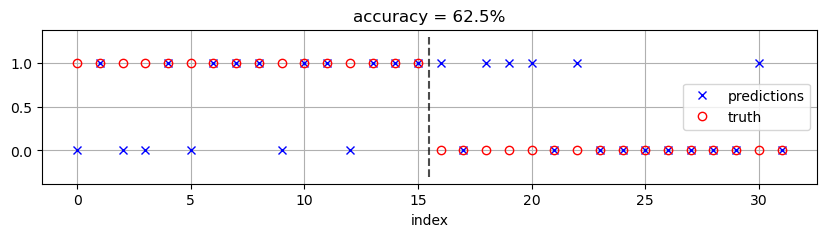

In [11]:
# evalute skill and plot actual predictions
print("training set:")
classification_skill(predictions_train, Y_train)
print("test     set:")
classification_skill(predictions_test, Y_test)

fig = classification_plot(predictions_test, Y_test)

So the above shows that we got all the training set classficiation correct (which is not too surprising), but it struggles on the test set, giving an accuracy that is not dissimilar to what we had last time with `sklearn`, so we have some consistency with previous results at least.

In the below code I am going to define two more networks, one to have ReLU activation and the other to have `hidden_layer=(200, 50)`, exactly like the other example I considered last time with `sklearn`. These give roughly the same amount of skill as detailed last time.

> NOTE: Word of warning here. If you only run the training loop without re-initialising the model with `model = nn_classify_pets()` steps etc. it will probably restart from where you **just left off** rather than from zero. This is because the taping hasn't been cleared. If you have called `model` accordingly then it might do some intermediate taping, which may give you some weird things. It is best to start fresh, unless you really do mean to do restarts for whatever reason.

In [12]:
# define the networks

class nn_classify_pets_relu(nn.Module):
    def __init__(self):  # specify input dims below
        super(nn_classify_pets_relu, self).__init__()

        # nest it in one go
        self.layers = nn.Sequential(
            nn.Linear(64**2, 100),
            nn.ReLU(),              # with activation
            nn.Linear(100, 2)
        )

    # actual model structure: input -> hidden layer -> outputs, ReLU on input and hidden
    def forward(self, x):
        out =  self.layers(x)
        return out

class nn_classify_pets_2layers(nn.Module):
    def __init__(self):  # specify input dims below
        super(nn_classify_pets_2layers, self).__init__()

        # nest it in one go (two hidden layers, 64**2 -> 200 -> 50 -> 2)
        self.layers = nn.Sequential(
            nn.Linear(64**2, 200),
            nn.Linear(200, 50),
            nn.Linear(50, 2)
        )

    def forward(self, x):
        out =  self.layers(x)
        return out

Epoch 20/200, Train Loss: 0.0027, Test Loss: 2.1034
Epoch 40/200, Train Loss: 0.0003, Test Loss: 2.4836
Epoch 60/200, Train Loss: 0.0001, Test Loss: 2.6029
Epoch 80/200, Train Loss: 0.0001, Test Loss: 2.6332
Epoch 100/200, Train Loss: 0.0001, Test Loss: 2.6457
Epoch 120/200, Train Loss: 0.0001, Test Loss: 2.6660
Epoch 140/200, Train Loss: 0.0001, Test Loss: 2.6851
Epoch 160/200, Train Loss: 0.0000, Test Loss: 2.7039
Epoch 180/200, Train Loss: 0.0000, Test Loss: 2.7219
Epoch 200/200, Train Loss: 0.0000, Test Loss: 2.7396


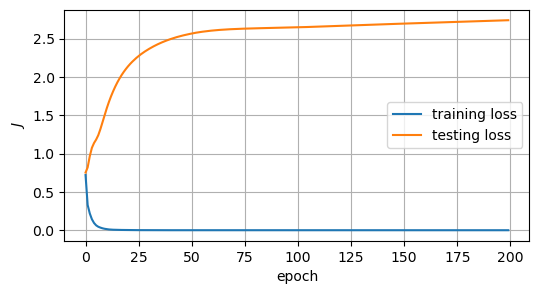

In [13]:
# initialisations
torch.manual_seed(1234)

model = nn_classify_pets_relu()
learning_rate = 0.001
J = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # default is 0.001

# do the actual training
model, train_J, test_J = training(model, optimizer, J, X_train, Y_train, X_test, Y_test,
                                  num_epochs=200, out_epoch=20)

fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
ax.plot(train_J, label="training loss")
ax.plot(test_J, label="testing loss")
ax.set_xlabel("epoch")
ax.set_ylabel(r"$J$")
ax.grid()
ax.legend();

training set:
overall skill: 128 correct out of 128 (100.00%)
 
test     set:
overall skill: 18 correct out of 32 (56.25%)
 


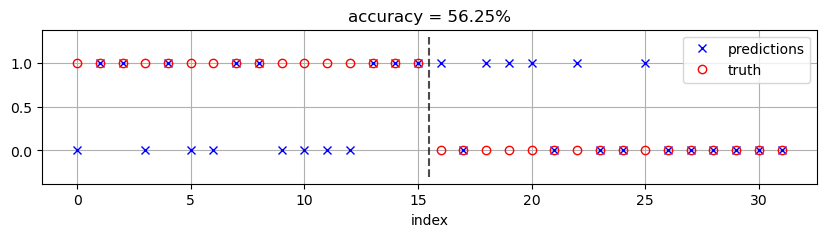

In [14]:
with torch.no_grad():
    predictions_train = model(X_train)
    predictions_test = model(X_test)

print("training set:")
classification_skill(predictions_train, Y_train)
print("test     set:")
classification_skill(predictions_test, Y_test)

fig = classification_plot(predictions_test, Y_test)

Epoch 20/200, Train Loss: 0.0079, Test Loss: 1.9892
Epoch 40/200, Train Loss: 0.0002, Test Loss: 3.3353
Epoch 60/200, Train Loss: 0.0001, Test Loss: 3.5303
Epoch 80/200, Train Loss: 0.0001, Test Loss: 3.5952
Epoch 100/200, Train Loss: 0.0000, Test Loss: 3.6517
Epoch 120/200, Train Loss: 0.0000, Test Loss: 3.6820
Epoch 140/200, Train Loss: 0.0000, Test Loss: 3.7072
Epoch 160/200, Train Loss: 0.0000, Test Loss: 3.7333
Epoch 180/200, Train Loss: 0.0000, Test Loss: 3.7585
Epoch 200/200, Train Loss: 0.0000, Test Loss: 3.7825


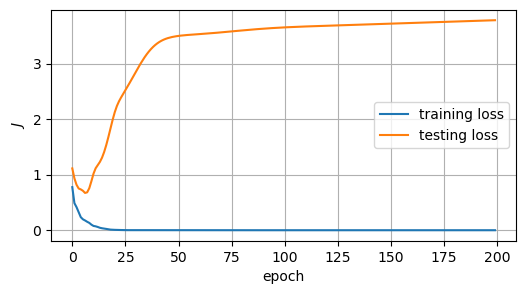

In [15]:
# initialisations
torch.manual_seed(1234)

model = nn_classify_pets_2layers()
learning_rate = 0.001
J = nn.CrossEntropyLoss()  # for classification tasks, H = -p log q
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # default is 0.001

# do the actual training
model, train_J, test_J = training(model, optimizer, J, X_train, Y_train, X_test, Y_test,
                                  num_epochs=200, out_epoch=20)

fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
ax.plot(train_J, label="training loss")
ax.plot(test_J, label="testing loss")
ax.set_xlabel("epoch")
ax.set_ylabel(r"$J$")
ax.grid()
ax.legend();

training set:
overall skill: 128 correct out of 128 (100.00%)
 
test     set:
overall skill: 23 correct out of 32 (71.88%)
 


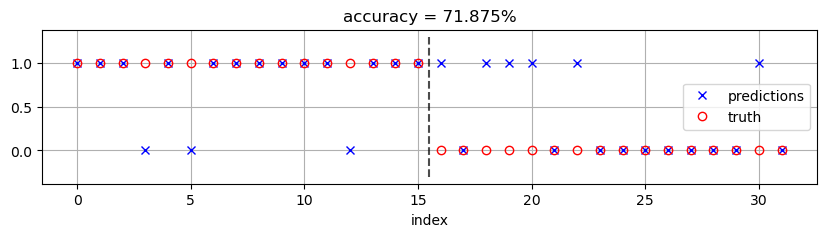

In [16]:
with torch.no_grad():
    predictions_train = model(X_train)
    predictions_test = model(X_test)

print("training set:")
classification_skill(predictions_train, Y_train)
print("test     set:")
classification_skill(predictions_test, Y_test)

fig = classification_plot(predictions_test, Y_test)

To close to very quick intro to using `PyTorch`, we can print out the model as `model.state_dict()`. This can then be saved and loaded accordingly as

```
    torch.save(model.state_dict(), "model_001.pth")
    print("Saved PyTorch Model State to model_001.pth")
    model = nn_model()  # or whatever you defined the class to be
    model.load_state_dict(torch.load("model_001.pth"))
```

In [17]:
# print out the mode to have a look
model.state_dict()

OrderedDict([('layers.0.weight',
              tensor([[-1.0672e-02,  1.5099e-03, -1.7481e-03,  ...,  2.3436e-02,
                        1.8628e-02,  9.4447e-03],
                      [-9.0012e-03,  5.6276e-03, -2.2733e-02,  ..., -1.4980e-02,
                       -2.0391e-02, -8.9314e-03],
                      [ 8.4298e-03,  3.1016e-03,  1.6678e-03,  ..., -1.5787e-02,
                       -7.6064e-04, -6.3680e-03],
                      ...,
                      [ 9.1174e-03, -6.3044e-03, -2.1344e-02,  ..., -9.9527e-03,
                       -1.2452e-02, -1.8616e-02],
                      [-2.3020e-04,  7.2297e-03,  2.3432e-05,  ..., -1.1739e-02,
                       -1.9655e-02, -5.2908e-03],
                      [-1.0795e-02, -1.9597e-02, -1.6283e-02,  ..., -2.3702e-02,
                        5.5769e-03,  4.3272e-03]])),
             ('layers.0.bias',
              tensor([ 6.2200e-03, -3.6058e-03,  1.1059e-02,  1.2155e-02,  2.2094e-02,
                       4.0482e-03

> <span style="color:red">Q.</span> I have personally not found decreasing `learning_rate` to help with the classification task that much, but see what happens if you decrease it further. You could try increasing it, but for me the loss function on the test set blows up fairly spectacularly...
>
> <span style="color:red">Q.</span> Try exploring other classification relevant loss functions.
>
> <span style="color:red">Q.</span> You could try also the regression problem, although it might be easier to see this after the CNN sections below where I demonstrate it once anyway.

---
## b) Convolutions

First we talk about what ***convolutions*** are, then what ***Convolutional Neural Networks*** (CNNs) are should be fairly self-explanatory. Convolutions were sort of introducted in OCES 3301 in relation to ***filtering*** (in the context of time series data). Mathematically, for a ***kernel function*** $G(x, x')$, the convolution of $f(x)$ with $G(x, x')$, denoted $f\ast G$ is defined as (for the continuous case)
\begin{equation*}
    (f \ast G) (x) = \int f(x') G(x, x')\; \mathrm{d}x'.
\end{equation*}
For doing this in higher dimensions you just add more variables in, e.g. $f(x,y)$ and $G(x,x',y,y')$.

> NOTE: Most works you see would presumably use $K$ for kernel. I happen to use $G$ because I am used to seeing it as a ***Green's function***.

This looks a bit confusing maybe, but it's actually quite simple and easier to explain with a picture and the discrete case. Here the kernel $G$ is basically the red thing.

<img src="https://i.imgur.com/NbN8svq.jpeg" width="600" alt='conv2d'>

Here I chose my kernel has ***size*** `(width, height) = (2, 2)` (because it's 2 by 2), and I chose uniform weights of $1/4$ for all of them. I throw down the kernel onto the array (the solid red box), then act on it as
\begin{equation*}
    \frac{1}{4}\cdot 1 + \frac{1}{4}\cdot 2 + \frac{1}{4}\cdot 5 + \frac{1}{4}\cdot 6 = \frac{1+2+5+6}{4} = \frac{14}{4} = 3.5,
\end{equation*}
and that becomes out new top-left entry in the result on the right.

I would then move that kernel around the original array, in this case with a ***stride*** of `(horizontal, vertical) = (1, 1)`. My top right entry in the new array would be
\begin{equation*}
    \frac{3+4+7+8}{4} = \frac{22}{4} = 5.5,
\end{equation*}
and we continue until we have done the whole array. In the definition of $(f \ast G)$ above as an integral, that's what the integral over the dummy variable $x'$ means: you slide the kernel $G$ along the function $x$, do an integral, and you do this for all possible values.

In the above discrete example, if my input is a `(4, 4)` array, then my convolved output would be `(3, 3)` with a size of 2 and stride of 1 (assuming my kernel is square in this case so I don't talk about the other dimension). Thus a convolution by default **reduces** the dimensionality, but picks out some of the essence of the features (e.g. the kernel above basically does an averaging over a window, and removes small-scale features that might not be important for learning).

If I don't like the changes of shapes for whatever reason I can decide to do some ***padding***. In this case a ***zero padding*** would bulk out the array (right and bottom) edges with zeros, and then you pass a kernel through; my initial input is of size `(4, 4)`, padding makes it size `(5, 5)`, so my convolved ouptut would be `(4, 4)`. The zero padding leads to the calculations
\begin{equation*}
    \frac{4+0+8+0}{4} = \frac{12}{4} = 3, \qquad \frac{16+0+0+0}{4} = 4,
\end{equation*}
as seen in the relevant entries above.

> NOTE: Neither the kernel size, strides and/or paddings need to be square/uniform. You can do whatever you like in principle, but certain choices makes setting up the CNN a bit easier; see later uses in PyTorch.
>
> Strictly speaking the above is a ***cross-correlation*** and not a convolution, which requires some flips along the dimensions. In practice it doesn't really matter, because it just means the thing that ends up being trained is the flipped version of the convolutional layer, but two flips cancel out.

***Pooling*** works similarly but the operations and defaults are different. The example below shows what would be called ***max pooling***:

<img src="https://i.imgur.com/w2uERAj.jpeg" width="600" alt='pooling'>

The max pooling part is in green and it picks out the maximum of the values covered by the pooling kernel; because of how I set up the array, this basically picks out the value at the  bottom right corner covered by the pooling kernel. A thing to be aware of is that by default the stride of pooling layers is **equal** to the size of the kernel; in this example that ends up squashing the input array down from size `(4, 4)` to `(2, 2)`. You can further imagine other operations one could do specify (e.g. averaging, fractional maximums).

### Implementation in `PyTorch`

To see what these things do I am going to borrow the help of the three ad-hoc TAs and explicitly specify my convolution and pooling layers. Summoning the TAs first.

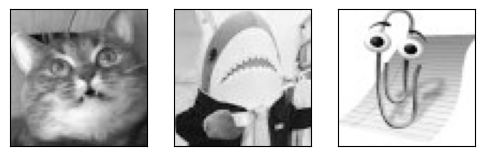

In [18]:
import requests
from PIL import Image
from io import BytesIO

targets_path = {
    "miffy_gormless" : "https://raw.githubusercontent.com/julianmak/OCES4303_ML_ocean/refs/heads/main/miffy_gormless.jpg",
    "blauhaj" : "https://raw.githubusercontent.com/julianmak/OCES4303_ML_ocean/refs/heads/main/blauhaj.jpg",
    "clippy" : "https://raw.githubusercontent.com/julianmak/OCES4303_ML_ocean/refs/heads/main/clippy.jpg",
}

targets = {}

for file_name, file_url in targets_path.items():
    response = requests.get(file_url)
    targets[file_name] = Image.open(BytesIO(response.content))

# do some plots to show decomposition
fig = plt.figure(figsize=(6, 2.5))

i = 0
for key in targets:
    X = np.array(targets[key])
    ax = plt.subplot(1, 3, i+1)
    ax.imshow(X, cmap="gray")
    ax.set_xticks([]); ax.set_yticks([]);
    i += 1    

I am going to define some three by three kernels and hit the ad-hoc TAs with those. Things I am doing are:

* Creating a dictionary `kernels` that will be cycled through. Each of these have a name and I am defining the things using the `torch.tensor` object straight away (I could have defined it as a numpy array then convert them into `LongTensors` accordingly).
* The image input is of size `(64, 64)`, but I promote them to size `(1, 1, 64, 64)` tensors via `.expand()`. The two `1`s are for 1 sample (because it's per image) and 1 channel (because it's grayscale).
* My kernels are promoted from `(3, 3)` to `(1, 1, 3, 3)` for the same reason.

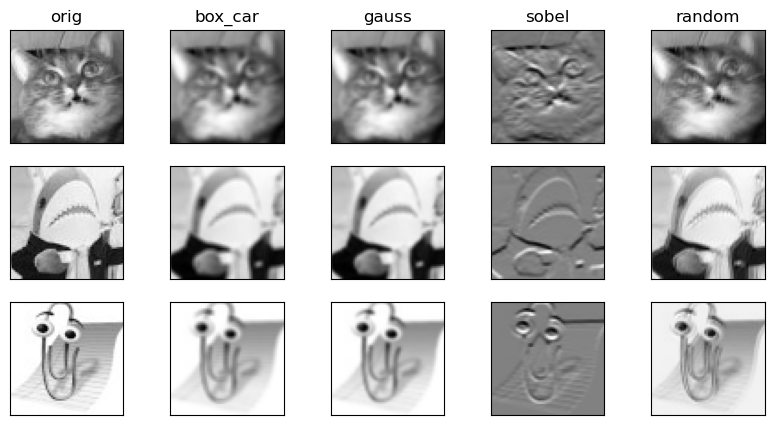

In [19]:
# plots to show convolutions with some fixed kernels
torch.manual_seed(4167) # specify a seed to fix the randomness

kernels = {"box_car" : torch.tensor([[1/9, 1/9, 1/9], [1/9, 1/9, 1/9], [1/9, 1/9, 1/9]]),
           "gauss" : torch.tensor([[1/16, 2/16, 1/16], [2/16, 4/16, 2/16], [1/16, 2/16, 1/16]]),
           "sobel" : torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]]),
           "random" : torch.randn(3, 3),
          }

fig = plt.figure(figsize=(10, 5))

i = 0
for key in targets:
    X = np.array(targets[key])
    X = torch.FloatTensor(X).expand(1, 1, 64, 64)

    j = 0
    ax = plt.subplot(len(targets), len(kernels)+1, 5*i + j+1)
    ax.imshow(X[0, 0, :, :], cmap="gray")
    ax.set_xticks([]); ax.set_yticks([]);
    if i == 0:
        ax.set_title("orig")
        
    for kernel in kernels:
        j += 1
        weights = kernels[kernel].expand(1, 1, 3, 3)
        X_conv = nn.functional.conv2d(X, weights)
        ax = plt.subplot(len(targets), len(kernels)+1, 5*i + j+1)
        ax.imshow(X_conv[0, 0, :, :], cmap="gray")
        ax.set_xticks([]); ax.set_yticks([]);
        if i == 0:
            ax.set_title(f"{kernel}")
        
    i += 1

I've chosen two that does the blurring and one that is for edge detection. The random one with the chosen seed does some sort of jiggling instead. The output in this case has shape `(62, 62)`. This comes from the formula (only showing one of these)
\begin{equation*}
    H_{\rm out} = \left\lfloor \frac{H_{\rm out} + 2\mbox{padding} - \mbox{dilate}(\mbox{kernel size}-1) + 1}{\mbox{stride}} + 1\right\rfloor,
\end{equation*}
where $\lfloor\cdot\rfloor$ is the floor function that takes the integer part of the answer. By default there is no padding, stride is 1, and dilation (look up what that is if you want) is 0, and input size is 64, so
\begin{equation*}
    H_{\rm out} = \left\lfloor \frac{64 + 2\cdot0 - 1(3-1) - 1}{1} + 1\right\rfloor = \left\lfloor 64 + 0 - 2 - 1 + 1\right\rfloor = 62.
\end{equation*}

We do the same for a few choices of pooling, all of them with kernel size `(2, 2)`.

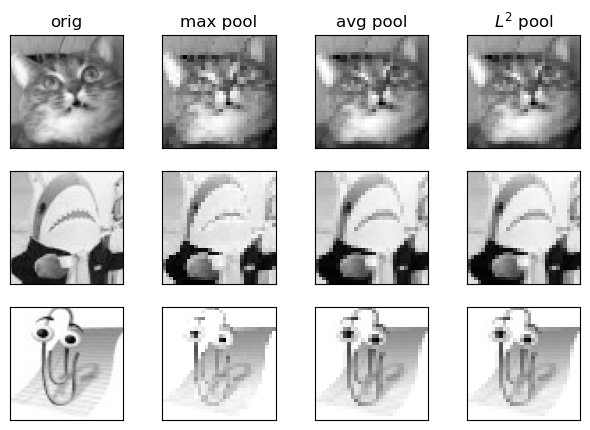

In [20]:
# plots to show effect of pooling
fig = plt.figure(figsize=(9.5, 5))

i = 0
for key in targets:
    X = np.array(targets[key])
    X = torch.FloatTensor(X).expand(1, 1, 64, 64)

    ax = plt.subplot(len(targets), 4+1, 5*i + 1)
    ax.imshow(X[0, 0, :, :], cmap="gray")
    ax.set_xticks([]); ax.set_yticks([]);
    if i == 0:
        ax.set_title("orig")
        
    X_pool = nn.functional.max_pool2d(X, (2, 2))
    ax = plt.subplot(len(targets), 4+1, 5*i + 2)
    ax.imshow(X_pool[0, 0, :, :], cmap="gray")
    ax.set_xticks([]); ax.set_yticks([]);
    if i == 0:
        ax.set_title(f"max pool")
        
    X_pool = nn.functional.avg_pool2d(X, (2, 2))
    ax = plt.subplot(len(targets), 4+1, 5*i + 3)
    ax.imshow(X_pool[0, 0, :, :], cmap="gray")
    ax.set_xticks([]); ax.set_yticks([]);
    if i == 0:
        ax.set_title(f"avg pool")
        
    X_pool = nn.functional.lp_pool2d(X, 2, (2, 2))  # (input, type, kernel size)
    ax = plt.subplot(len(targets), 4+1, 5*i + 4)
    ax.imshow(X_pool[0, 0, :, :], cmap="gray")
    ax.set_xticks([]); ax.set_yticks([]);
    if i == 0:
        ax.set_title(f"$L^2$ pool")
        
    i += 1

Here the outputs have size `(32, 32)` following the above formula but noting that stride by default is the same size as the kernel, so we have instead
\begin{equation*}
    H_{\rm out} = \left\lfloor \frac{64 + 2\cdot0 - 1(2-1) - 1}{2} + 1\right\rfloor = \left\lfloor \frac{64 + 0 - 1 - 1}{2} + 1\right\rfloor = 31 + 1 = 32.
\end{equation*}

This calculation, if slightly annoying, are important for later on when setting up the CNNs.

> <span style="color:red">Q.</span> See if you can interpret why the non-random kernels are doing what they are doing. Then have a look at the random one and see why it is doing whatever it is they are doing.
> 
> <span style="color:red">Q.</span> Try writing your own kernels for doing the convolution.
> 
> <span style="color:red">Q.</span> There are other choices of pooling, have a look at those. (Be a bit careful with `fractional_max_pool2d` if you do use it.)
>
> <span style="color:red">Q.</span> The above was demonstrated for data with one channel (grayscale images). Try adapting this to the coloured broccolie image that I loaded at some point (e.g. session 1) and see how you would modify the kernels accordingly, noting we now have three channels to deal with.

## c) CNNs with `PyTorch`

In a nutshell, what CNNs do is that entires in the kernels of the convolutional layers are themselves weights that can be adjusted, and are thus part of the model parameters or control variables that are to be learned, but otherwise you wrap them up exactly as you would for MLPs with hidden layers etc. as usual. You might suspect CNNs have the following advantages over the MLPs because:

* Convolution operations are richer, and leaves specific structures in the data intact that may be useful for classification/regression.
* The convolutions and pooling inherently reduce the dimension in the data, which is potentially useful for learning, and definitely a bonus for computation purposes.
* The convolutions with a small kernel inherently has fewer model parameters, which also provides additional controls on the feature space dimension.

CNNs work particularly well when there are structures that are inherent in the data, such as images.

### Classification

We now have all the pieces we need to construct CNNs. Going to do the classification problem first, as this is slightly easier problem than regression. Loading the data and doing the relevant processing here again just to avoid possible contamination.

In [21]:
# shape of "cats" and "dogs" here is (pixels, index), so it is already flattened
n = 64  # take the first 80% (out of 80 entries) of the data just because

X_train = np.concatenate((X_cats[:n, :], X_dogs[:n, :]), axis=0)  # combine
Y_train = np.concatenate((np.ones(n), np.zeros(n)))         # label: cats = 1 and dogs = 0

X_test = np.concatenate((X_cats[n::, :], X_dogs[n::, :]), axis=0)
Y_test = np.concatenate((np.ones(80-n), np.zeros(80-n)))

# scale and redefine the data
scaler = StandardScaler()
scaler.fit(X_train)
X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)

X_train, X_test = torch.FloatTensor(X_train), torch.FloatTensor(X_test)
Y_train, Y_test = torch.LongTensor(Y_train), torch.LongTensor(Y_test)

The only new thing I need to do really is to specify the structure of the CNN. The one below I took from a MNIST classification task, but I reduced various values for the sake of it. The structure is that we have

* Input image of size `(64, 64)`, grayscale so one channel, thus input size of `(n, 1, 64, 64)`.
* First convolutional layer that does
  - 2d convolution with `(in channel, out channel, kernel size) = (1, 6, 5)`, so input is now of size `(6, 60, 60)` using the above formula (in this case you take 5-1 = 4 pixels off both ends)
  - activation with ReLU
  - max pool of size 2 to give an output of `(6, 30, 30)` using above formula (or in this case the number of pixels is even, so you can basically divide by 2)
* Second convolutional layer that does
  - 2d convolution with `(6, 10, 5)`, so input is now of size `(10, 26, 26)` (formula, or shave 4 pixels off)
  - activation with ReLU
  - max pool of size 2 to give an output of `(10, 13, 13)` (formula, or basically divide by 2)
* Flatten the image so the input is now a tensor of size `(10 * 13 * 13)` using `x.view(-1, 10*13*13)`
* Passed through some linear layers as in the MLP case as `10 * 13 * 13 -> 60 -> 30 -> 2` with ReLU activation as appropriate. The last one is `2` because we only have two outputs (cats or dogs).

In [22]:
class cnn_classification(nn.Module):
    def __init__(self):
        super(cnn_classification, self).__init__()

        # input at (1, 64, 64)

        # convolutional layer 1 & max pool layer 1
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 6, 5),    # now (6, 60, 60)
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),  # now (6, 30, 30)
        )

        # convolutional layer 2 & max pool layer 2
        self.layer2 = nn.Sequential(
            nn.Conv2d(6, 10, 5),   # now (10, 26, 26)
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),  # now (10, 13, 13)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(10 * 13 * 13, 60),
            nn.ReLU(),
            nn.Linear(60, 30),
            nn.ReLU(),
            nn.Linear(30, 2)      # because two possible outputs
        )
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(-1, 10 * 13 * 13)
        out = self.layer3(out)
        return out

We use entropy loss and Adam as before. We can leverage the same training loops as previously defined, and once we massage the data accordingly (because the CNN is expecting images of size `(n, 1, 64, 64)` rather `(n, 64*64)`), then we can pass that to the subroutine for model training. We proceed straight away to the plotting of the loss curve and evaluation of model skill on test set.

> NOTE: I find I need a slightly smaller learning rate here.

In [23]:
# training a CNN
torch.manual_seed(1234)

model = cnn_classification()
learning_rate = 0.00005
J = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # default is 0.001

# change the shape of input for the CNN
X_train = X_train.view(-1, 1, 64, 64)
X_test = X_test.view(-1, 1, 64, 64)

# do the actual training
model, train_J, test_J = training(model, optimizer, J, 
                                  X_train, Y_train,
                                  X_test, Y_test,
                                  num_epochs=300, out_epoch=30)

Epoch 30/300, Train Loss: 0.6637, Test Loss: 0.6842
Epoch 60/300, Train Loss: 0.5670, Test Loss: 0.6365
Epoch 90/300, Train Loss: 0.4210, Test Loss: 0.5674
Epoch 120/300, Train Loss: 0.2917, Test Loss: 0.5175
Epoch 150/300, Train Loss: 0.2051, Test Loss: 0.5003
Epoch 180/300, Train Loss: 0.1443, Test Loss: 0.5019
Epoch 210/300, Train Loss: 0.1009, Test Loss: 0.5210
Epoch 240/300, Train Loss: 0.0698, Test Loss: 0.5535
Epoch 270/300, Train Loss: 0.0481, Test Loss: 0.5993
Epoch 300/300, Train Loss: 0.0334, Test Loss: 0.6492


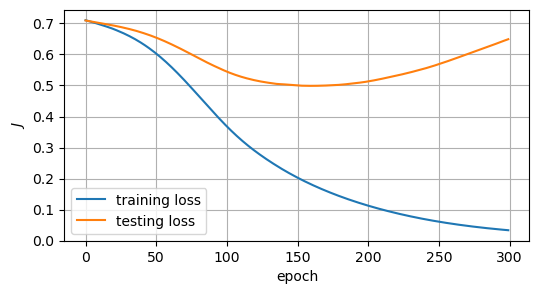

In [24]:
fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
ax.plot(train_J, label="training loss")
ax.plot(test_J, label="testing loss")
ax.set_xlabel("epoch")
ax.set_ylabel(r"$J$")
ax.grid()
ax.legend();

training set:
overall skill: 128 correct out of 128 (100.00%)
 
test     set:
overall skill: 24 correct out of 32 (75.00%)
 


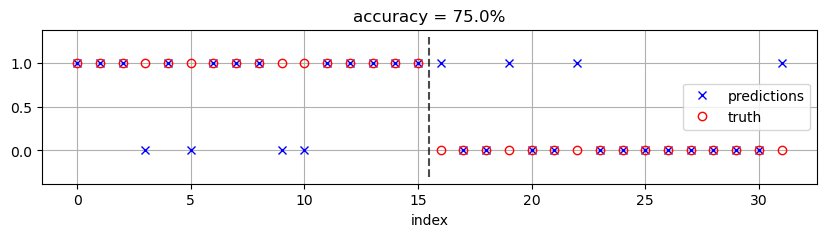

In [25]:
with torch.no_grad():
    predictions_train = model(X_train)
    predictions_test = model(X_test)

print("training set:")
classification_skill(predictions_train, Y_train)
print("test     set:")
classification_skill(predictions_test, Y_test)

fig = classification_plot(predictions_test, Y_test)

Looks ok? Could probably tune it accordingly to get a better score (e.g. learning rates, details of the layers). Also, these things tend to work better with more samples; I've only given it 64 samples each of cats and dogs.

### CNN for regression

For the regression problem I am going to predict top half from bottom or vice-versa just with cats. More or less going to use the same structure, but the differences are some numbers, namely
* The input is now of size `(n, 1, 64, 32)`, so I need to keep track of how the image sizes change as it passes through the layers.
* Once I get to the linear layers I need to expand it back to images of size $64\times32 = 2048$, so the linear layers have different numbers in them for the scaling up of the values (before it was scaling down of values to $2$).

The various relevant numbers are given below as in-line comments.

> NOTE: If we use the PyTorch convention the inputs should probably be of size `(sample size, channel, height, width) = (n, 1, 32, 64)`, but again it practice it doesn't really matter because the dimension is just a label, and as long as I do things consistently it should be fine.

In [26]:
# cnn adjusted for regression
class cnn_regression(nn.Module):
    def __init__(self):
        super(cnn_regression, self).__init__()

        # input at (1, 64, 32)

        # convolutional layer 1 & max pool layer 1
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 6, 5),    # now (6, 60, 28)
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),  # now (6, 30, 14)
        )

        # convolutional layer 2 & max pool layer 2
        self.layer2 = nn.Sequential(
            nn.Conv2d(6, 10, 5),   # now (10, 26, 10)
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),  # now (10, 13, 5)
        )

        # a more bulky final linear layer
        # self.layer3 = nn.Sequential(
            # nn.Linear(10 * 13 * 5, 1000), # expand these up to 2048 eventually
            # nn.ReLU(),
            # nn.Linear(1000, 1500),
            # nn.ReLU(),
            # nn.Linear(1500, 2048)
        # )

        self.layer3 = nn.Sequential(
            nn.Linear(10 * 13 * 5, 1000), # expand these up to 2048 eventually
            nn.ReLU(),
            nn.Linear(1000, 2048)
        )
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(-1, 10 * 13 * 5)
        out = self.layer3(out)  # this block is going to be too big no?
        return out

Below is the same code as before to split the image in half and doing the data conversion (we now what `FloatTensors` for everything).

In [27]:
n = 64  # take the first 80% (out of 80 entries) of the data just because

# subroutine to split top and bottom half of pixels: reshape, split, then flatten for sklearn
def split_top_bottom(data):
    n, width = data.shape[0], int(np.sqrt(data.shape[1]))
    data = np.reshape(data, (n, width, width))
    top_half, bottom_half = data[:, :, 0:width//2], data[:, :, width//2::]
    top_half = np.reshape(top_half, (n, width*width//2))
    bottom_half = np.reshape(bottom_half, (n, width*width//2))

    return top_half, bottom_half

# shape of "cats" here is (pixels, index), so it is already flattened
n = 64

# manually split up into train and test
X_train, Y_train = split_top_bottom(X_cats[:n, :])
X_test, Y_test = split_top_bottom(X_cats[n::, :])

# scale the data
scale_X, scale_Y = StandardScaler().fit(X_train), StandardScaler().fit(Y_train)
X_train, X_test = scale_X.transform(X_train), scale_X.transform(X_test)
Y_train, Y_test = scale_Y.transform(Y_train), scale_Y.transform(Y_test)

# prep the input data: FloatTensors for regression
X_train, Y_train = torch.FloatTensor(X_train), torch.FloatTensor(Y_train)
X_test, Y_test = torch.FloatTensor(X_test), torch.FloatTensor(Y_test)

The below code defines the regression problem by specifying the choice of loss (in this case MSE loss), using Adam as before, and pass it through the training again.

> NOTE: The below might be a slow. If we want to not change the CNN structure then we could speed it up by ***batching***; see extended exercise on what that is.
>
> <span style="color:red">WARNING!</span> If the training ends up eating up too much of your available memory on the computer, I would suggest removing some layers, particularly the linear ones at the end.

In [28]:
# regression example: prediction bottom from top

torch.manual_seed(1234)

model = cnn_regression()
learning_rate = 0.001  # larger value also seems ok for regression
J = nn.MSELoss()  # one choice for regression problems
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # default is 0.001

# change the shape of input for the CNN
# X's go in as a 2d to be pass through the Conv2d
X_train, X_test = X_train.view(-1, 1, 64, 32), X_test.view(-1, 1, 64, 32)

# Y's go in as 1d tensors along feature dimension after the linear layer
# no reshape here, but need to reshape for visualising later

# do the actual training
model, train_J, test_J = training(model, optimizer, J, 
                                  X_train, Y_train,
                                  X_test, Y_test,
                                  num_epochs=300, out_epoch=20)

Epoch 20/300, Train Loss: 0.5220, Test Loss: 0.7259
Epoch 40/300, Train Loss: 0.3120, Test Loss: 0.7967
Epoch 60/300, Train Loss: 0.1819, Test Loss: 0.7707
Epoch 80/300, Train Loss: 0.0974, Test Loss: 0.8107
Epoch 100/300, Train Loss: 0.0479, Test Loss: 0.8704
Epoch 120/300, Train Loss: 0.0280, Test Loss: 0.9195
Epoch 140/300, Train Loss: 0.0132, Test Loss: 0.9002
Epoch 160/300, Train Loss: 0.0070, Test Loss: 0.8976
Epoch 180/300, Train Loss: 0.0051, Test Loss: 0.9235
Epoch 200/300, Train Loss: 0.0019, Test Loss: 0.9142
Epoch 220/300, Train Loss: 0.0010, Test Loss: 0.9165
Epoch 240/300, Train Loss: 0.0050, Test Loss: 0.9751
Epoch 260/300, Train Loss: 0.0003, Test Loss: 0.9277
Epoch 280/300, Train Loss: 0.0002, Test Loss: 0.9204
Epoch 300/300, Train Loss: 0.0002, Test Loss: 0.9134


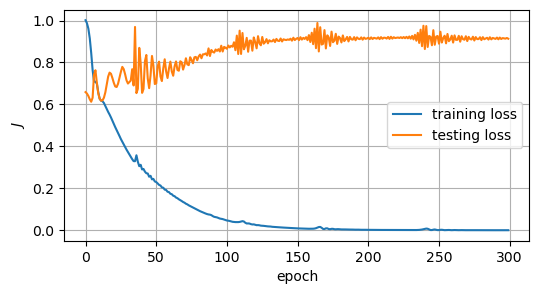

In [29]:
fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
ax.plot(train_J, label="training loss")
ax.plot(test_J, label="testing loss")
ax.set_xlabel("epoch")
ax.set_ylabel(r"$J$")
ax.grid()
ax.legend();

Below massages data accordingly (e.g. `(n, 1, 2048)` to `(n, 64, 32)`), makes the predictions and then plots out the results.

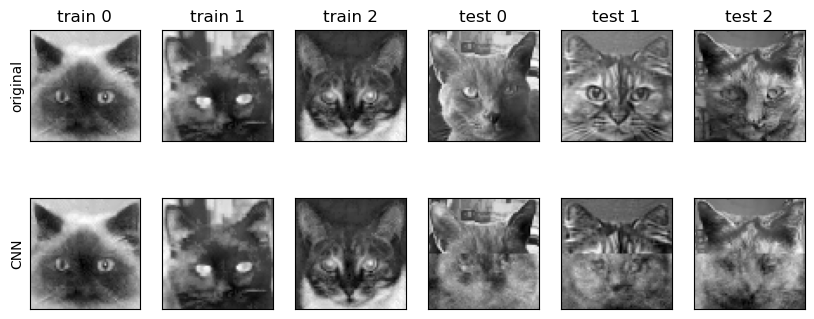

In [30]:
# could be passed accordingly to plotting commands (internally convert to np arrays presumably)
# going to convert here just so I can basically lift code directly from before
X_train_plot = X_train.view(-1, 64*32).numpy()
Y_train_plot = Y_train.numpy()

X_test_plot = X_test.view(-1, 64*32).numpy()
Y_test_plot = Y_test.numpy()

ind_train = np.arange(n)
np.random.shuffle(ind_train)

ind_test = np.arange(80-n)
np.random.shuffle(ind_test)

fig, ax = plt.subplots(figsize=(10, 4), nrows=2, ncols=6)

with torch.no_grad():
    Y_pred = model(X_train).view(-1, 64*32).numpy()

for j in range(0, 3):
    ind = ind_train[j]
    ax[0][j].imshow(np.hstack((np.reshape(X_train_plot[ind, :], (64, 32)), 
                               np.reshape(Y_train_plot[ind, :], (64, 32)))).T, 
                    cmap="gray")
    ax[0][j].set_title(f"train {j}")

    ax[1][j].imshow(np.hstack((np.reshape(X_train_plot[ind, :], (64, 32)), 
                               np.reshape(Y_pred[ind, :], (64, 32)))).T, 
                    cmap="gray")

with torch.no_grad():
    Y_pred = model(X_test).view(-1, 64*32).numpy()

for j in range(3, 6):
    ind = ind_test[j]
    ax[0][j].imshow(np.hstack((np.reshape(X_test_plot[ind, :], (64, 32)), 
                               np.reshape(Y_test_plot[ind, :], (64, 32)))).T, 
                    cmap="gray")
    ax[0][j].set_title(f"test {j-3}")

    ax[1][j].imshow(np.hstack((np.reshape(X_test_plot[ind, :], (64, 32)), 
                               np.reshape(Y_pred[ind, :], (64, 32)))).T, 
                    cmap="gray")

for i in range(2):
    for j in range(6):
        ax[i][j].set_xticks([]); ax[i][j].set_yticks([]);
        if j == 0:
            ax[0][j].set_ylabel("original")
            ax[1][j].set_ylabel("CNN")

Just for completeness, going to predict the top from the bottom. The code below basically only changes the data splitting part and plot ordering.

In [31]:
# do the reverse: predict top from bottom

# manually split up into train and test but flip the input/outputs
Y_train, X_train = split_top_bottom(X_cats[:n, :])
Y_test, X_test = split_top_bottom(X_cats[n::, :])

# scale the data
scale_X, scale_Y = StandardScaler().fit(X_train), StandardScaler().fit(Y_train)
X_train, X_test = scale_X.transform(X_train), scale_X.transform(X_test)
Y_train, Y_test = scale_Y.transform(Y_train), scale_Y.transform(Y_test)

# float tensors for regression
X_train, Y_train = torch.FloatTensor(X_train), torch.FloatTensor(Y_train)
X_test, Y_test = torch.FloatTensor(X_test), torch.FloatTensor(Y_test)

torch.manual_seed(1234)

model = cnn_regression()
learning_rate = 0.001  # larger value also seems ok for regression
J = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # default is 0.001

X_train, X_test = X_train.view(-1, 1, 64, 32), X_test.view(-1, 1, 64, 32)

model, train_J, test_J = training(model, optimizer, J, 
                                  X_train, Y_train,  
                                  X_test, Y_test,
                                  num_epochs=300, out_epoch=20)

Epoch 20/300, Train Loss: 0.4732, Test Loss: 0.8117
Epoch 40/300, Train Loss: 0.2673, Test Loss: 0.7178
Epoch 60/300, Train Loss: 0.1418, Test Loss: 0.7828
Epoch 80/300, Train Loss: 0.0780, Test Loss: 0.8357
Epoch 100/300, Train Loss: 0.0540, Test Loss: 0.8423
Epoch 120/300, Train Loss: 0.0216, Test Loss: 0.9000
Epoch 140/300, Train Loss: 0.0107, Test Loss: 0.9058
Epoch 160/300, Train Loss: 0.0055, Test Loss: 0.9166
Epoch 180/300, Train Loss: 0.0098, Test Loss: 0.9682
Epoch 200/300, Train Loss: 0.0018, Test Loss: 0.9120
Epoch 220/300, Train Loss: 0.0008, Test Loss: 0.9138
Epoch 240/300, Train Loss: 0.0003, Test Loss: 0.9194
Epoch 260/300, Train Loss: 0.0002, Test Loss: 0.9203
Epoch 280/300, Train Loss: 0.0027, Test Loss: 0.9331
Epoch 300/300, Train Loss: 0.0003, Test Loss: 0.9131


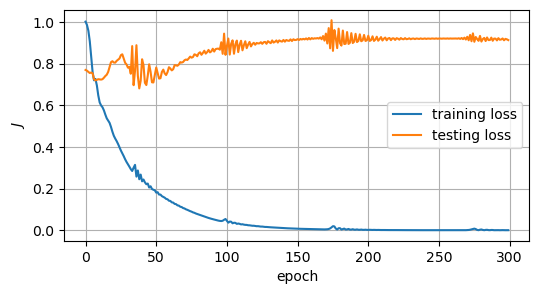

In [32]:
fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
ax.plot(train_J, label="training loss")
ax.plot(test_J, label="testing loss")
ax.set_xlabel("epoch")
ax.set_ylabel(r"$J$")
ax.grid()
ax.legend();

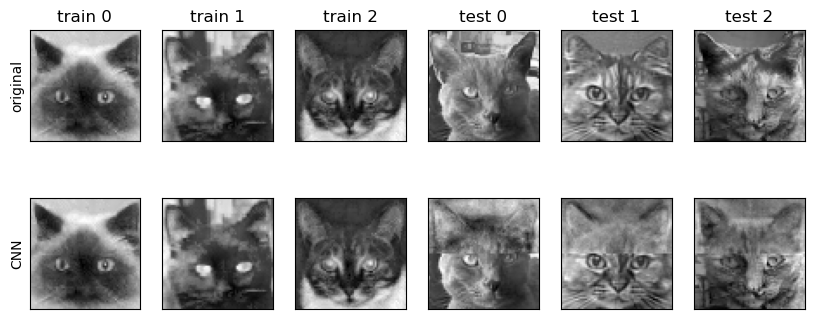

In [33]:
# could be passed accordingly to plotting commands (internally convert to np arrays presumably)
# going to convert here just so I can basically lift code directly from before
X_train_plot = X_train.view(-1, 64*32).numpy()
Y_train_plot = Y_train.numpy()

X_test_plot = X_test.view(-1, 64*32).numpy()
Y_test_plot = Y_test.numpy()

fig, ax = plt.subplots(figsize=(10, 4), nrows=2, ncols=6)

with torch.no_grad():
    Y_pred = model(X_train).view(-1, 64*32).numpy()

for j in range(0, 3):
    ind = ind_train[j]
    ax[0][j].imshow(np.hstack((np.reshape(Y_train_plot[ind, :], (64, 32)), 
                               np.reshape(X_train_plot[ind, :], (64, 32)))).T, 
                    cmap="gray")
    ax[0][j].set_title(f"train {j}")

    ax[1][j].imshow(np.hstack((np.reshape(Y_pred[ind, :], (64, 32)),
                               np.reshape(X_train_plot[ind, :], (64, 32)))).T, 
                    cmap="gray")

with torch.no_grad():
    Y_pred = model(X_test).view(-1, 64*32).numpy()

for j in range(3, 6):
    ind = ind_test[j]
    ax[0][j].imshow(np.hstack((np.reshape(Y_test_plot[ind, :], (64, 32)), 
                               np.reshape(X_test_plot[ind, :], (64, 32)))).T, 
                    cmap="gray")
    ax[0][j].set_title(f"test {j-3}")

    ax[1][j].imshow(np.hstack((np.reshape(Y_pred[ind, :], (64, 32)),
                               np.reshape(X_test_plot[ind, :], (64, 32)))).T, 
                    cmap="gray")

for i in range(2):
    for j in range(6):
        ax[i][j].set_xticks([]); ax[i][j].set_yticks([]);
        if j == 0:
            ax[0][j].set_ylabel("original")
            ax[1][j].set_ylabel("CNN")

> <span style="color:red">Q.</span> As in one of the exercises previously, consider doing classification with CNN but only on one half of the image.
>
> <span style="color:red">Q.</span> When I first made the notebooks I made a mistake and had 10 outputs instead of 2 for the present classification problem, however I seem to be getting better skill with the same settings (I got about 80% accuracy on the test set). Have a look at this and see if there is a reasoning for this or whether it is just a fluke.

----------------
# More involved exercises with this notebook

## 1) Further practice with pytorch: MLP with Penguins data

See how you might use `PyTorch` to do regression and classification problems in the penguins data.

I wouldn't use CNN for that personally, you could try it if you want.

## 2) CNN structure

Consider playing around with the sizes of the convolution and pooling layer sizes etc. I would stick with the classification problem because size of problem reasons.

## 3) Interfacing with `PyTorch Lightning` and/or `keras`

I haven't used it but you can in principle make your life even easier by leveraging interfaces for the underlying `PyTorch` and/or `TensorFlow` engines. [Lightning](https://lightning.ai/docs/pytorch/stable/) and [keras](https://keras.io/) are two such. You could try using that to simplify/group the chunks of code above in a more compact fashion.

> NOTE: I would try `keras`. It used to be that `keras` is a possible interface for `TensorFlow` and `Lightning` is the analogue of that for `PyTorch`, but `keras` is now supposedly sufficiently general to do either; try [here](https://keras.io/guides/writing_a_custom_training_loop_in_torch/) for a guide on how that would work with `PyTorch`.

## 4) `DataLoader` object and Batching

Have a look for example at [here](https://www.kaggle.com/code/jiazhuang/cnn-with-pytorch-for-beginners/notebook) for how to wrap up the image dataset above into a `DataLoader` object. This then allows further utilities imbued with the data to be passed accordingly to other pytorch objects.

The main one of interest is ***batching***, which makes the problem computationally nicer (although not necessarily improving your model as such). This is a bit like ***chunking*** when you use `xarray`: you split the data into smaller batches and do the training and gradient calculations using the smaller batches.

You might be able to do batching manually also; I didn't bother trying in this case.